In [1]:
import sys
from pathlib import Path
try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    PROJECT_ROOT = Path.cwd().resolve()
    while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "tofpetHelper").is_dir():
        PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

import tracker.utilities as Util
from tofpetTracker import load_raw_hits, load_geometry_assets, build_fibre_cache, build_bar_cache

data_file = str(PROJECT_ROOT / "data/teststand/Sept_coincs/sept15_360_ch25263032_lower_recon.root")
geo_file = str(PROJECT_ROOT / "tofpetHelper/base/geo_petsys.json")

raw_input = load_raw_hits(data_file, "tracks")
rdf = raw_input.get("rdf")
data = pd.DataFrame(rdf.AsNumpy(raw_input['reader'].branches.keys()))
print(f"ROOT entries:       {raw_input['reader'].entries}")
print(f"ROOT branches:      {sorted(raw_input['reader'].branches.keys())}")

geometry_detector = None
channel_map = None
channel_to_layer = {}
geometry_detector, channel_map, channel_to_layer = load_geometry_assets(geo_file)
fibre_cache = build_fibre_cache(channel_map)
bar_cache = build_bar_cache(geometry_detector)
print(f"Geometry channels:  {len(channel_map)}")
data.head(2)

ROOT entries:       232
ROOT branches:      ['fitPVE', 'fitchi2', 'fitdirs', 'fitgood', 'fitpoints', 'hitassid', 'hitchid', 'hitd', 'hitdetid', 'hitdt', 'hitevtid', 'hitlay', 'hitnrg1', 'hitnrg2', 'hitt', 'hitterr', 'hitx', 'hitxerr', 'hity', 'hityerr', 'hitz', 'hitzerr', 'p0', 'p1', 'p2', 'p3']
Geometry channels:  64


,hitx,hity,hitz,hitt,hitdt,hitd,hitxerr,hityerr,hitzerr,hitterr,...,hitnrg2,fitgood,fitchi2,fitPVE,fitpoints,fitdirs,p0,p1,p2,p3
0,"[865.0, 624.2811, 900.0]","[1177.6989, 1110.0, 631.14124]","[2439.0, 1617.0, 791.0]","[3.4603656e+09, 3.4603656e+09, 3.4603656e+09]","[-3.6339998, -8.162, -27.212]","[328.7301, 363.1281, 512.88586]","[20.0, 50.0, 20.0]","[50.0, 20.0, 50.0]","[10.0, 10.0, 10.0]","[10.0, 10.0, 10.0]",...,"[-0.051525116, -0.39449692, -0.082733154]",True,12.363457,0.956327,"[865.0, 1177.6989, 2439.0, 624.2811, 1110.0, 1...","[-0.028674267, 0.3207792, 0.9467199]","[771.4899, 1251.9185, 2439.0]","[796.38666, 973.3984, 1617.0]","[821.4046, 693.52295, 791.0]","[845.3624, 425.5067, 0.0]"
1,"[825.0, 500.0, 380.33847]","[1051.3198, 790.63666, 470.0]","[2439.0, 791.0, 0.0]","[4.04591e+09, 4.04591e+09, 4.04591e+09]","[-5.612, 6.8700004, -5.38]","[344.368, 243.43633, 342.53384]","[20.0, 20.0, 50.0]","[50.0, 50.0, 20.0]","[10.0, 10.0, 10.0]","[10.0, 10.0, 10.0]",...,"[-0.53961945, -0.12879181, 0.08362961]",True,2.006262,0.996685,"[825.0, 1051.3198, 2439.0, 500.0, 790.63666, 7...","[-0.17704822, -0.21768594, -0.9598264]","[819.74023, 1079.6255, 2439.0]","[668.1153, 893.19824, 1617.0]","[515.7525, 705.8638, 791.0]","[369.84576, 526.46716, 0.0]"


In [26]:
# Convert each dataframe row into a list of Util Hit objects keyed by event ID.
hit_dict = {}
for _, event in data.iterrows():
    eventid = int(event["hitevtid"])
    hit_dict[eventid] = [Util.datatypes.Hit(event["hitx"][idx],
                                            event["hity"][idx],
                                            event["hitz"][idx],
                                            event["hitt"][idx],
                                            event["hitxerr"][idx],
                                            event["hityerr"][idx],
                                            event["hitzerr"][idx],
                                            event["hitterr"][idx],
                                            event["hitlay"][idx],
                                            idx,
                                            event["hitdetid"][idx],
                                            1) for idx in range(len(event["hitx"]))]

Kalman result [Ax, Az, At]: [9.32273503e+02 1.61789785e+03 1.09836411e+10 9.10201786e-01
 2.37897568e+00 0.00000000e+00]
LS fit result [Ax, Az, At]: [-1602.6415974232712, 2395.036083496138, nan, 5.867265308998468, 5.117373338331577, 0.0010001897811286388]


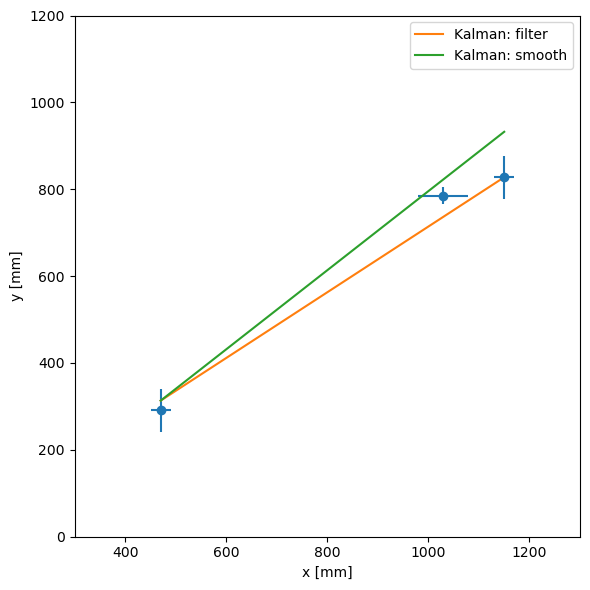

In [37]:
hits = hit_dict[6083]

# Run Kalman filter
kf = Util.track.run_kf(hits)
guess = Util.track.guess_track(hits)
fit_ls = Util.track.fit_track(hits, guess)

print(f"Kalman result [Ax, Az, At]: {kf.Xsm[0][:]}")
print(f"LS fit result [Ax, Az, At]: {fit_ls.values[:]}")

# Digitized hit
hit_x = [hit.x for hit in hits]
hit_y = [hit.y for hit in hits]
hit_z = [hit.z for hit in hits]
hit_t = [hit.t for hit in hits]
hit_x_err = [hit.x_err for hit in hits]
hit_y_err = [hit.y_err for hit in hits]
hit_z_err = [hit.z_err for hit in hits]
hit_t_err = [hit.t_err for hit in hits]
# Kalman-Filtred
fit_x = [hit[0] for hit in kf.Xf]
fit_z = [hit[1] for hit in kf.Xf]
fit_t = [hit[2] for hit in kf.Xf]
# Kalman-Smoothed
smooth_x = [hit[0] for hit in kf.Xsm]
smooth_z = [hit[1] for hit in kf.Xsm]
smooth_t = [hit[2] for hit in kf.Xsm]

plt.figure(figsize=(6, 6))
plt.errorbar(hit_y, hit_x, yerr = hit_x_err, xerr = hit_y_err, fmt="o")
plt.plot(hit_y[1:], fit_x, label="Kalman: filter")
plt.plot(hit_y[1:], smooth_x, label="Kalman: smooth")
plt.xlim(300, 1300)
plt.ylim(0, 1200)
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.legend()
plt.tight_layout()
plt.show()